# EDA: e-commerce recommendations

Retail Rocket events + categories + item properties.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('root:', ROOT)

root: /home/mle-user/mle-ecommerce-recommendations


{
  "rows": 2756101,
  "users": 1407580,
  "items": 235061,
  "events_by_type": {
    "view": 2664312,
    "addtocart": 69332,
    "transaction": 22457
  },
  "addtocart_share": 0.02515582701795036,
  "category_pairs": 1669,
  "items_with_category": 417053
}


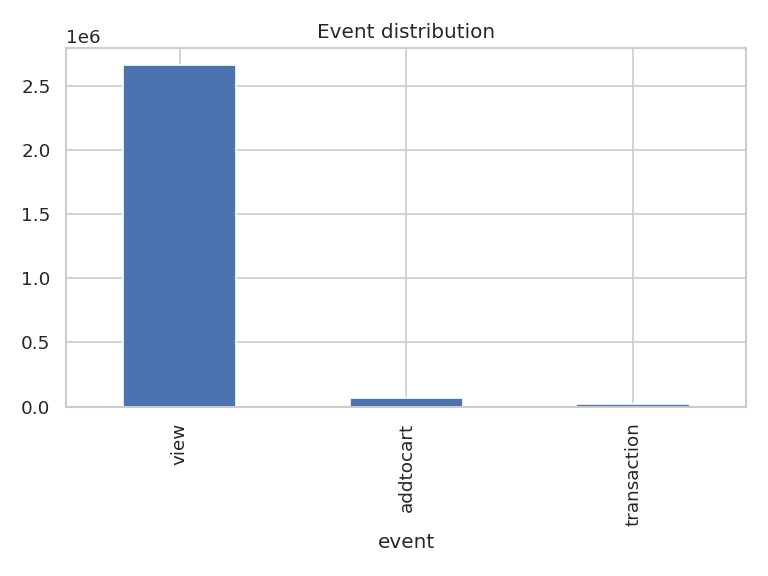

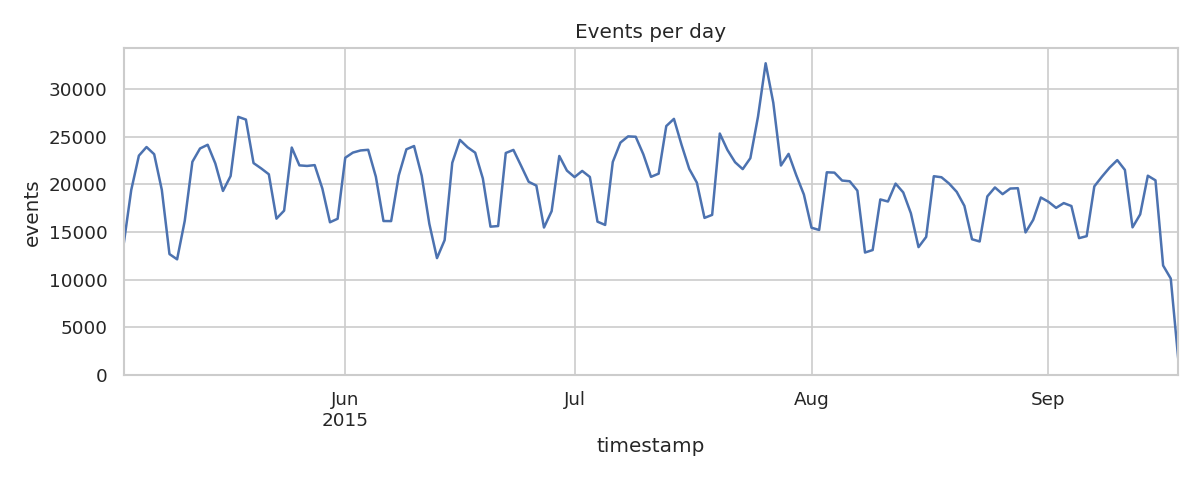

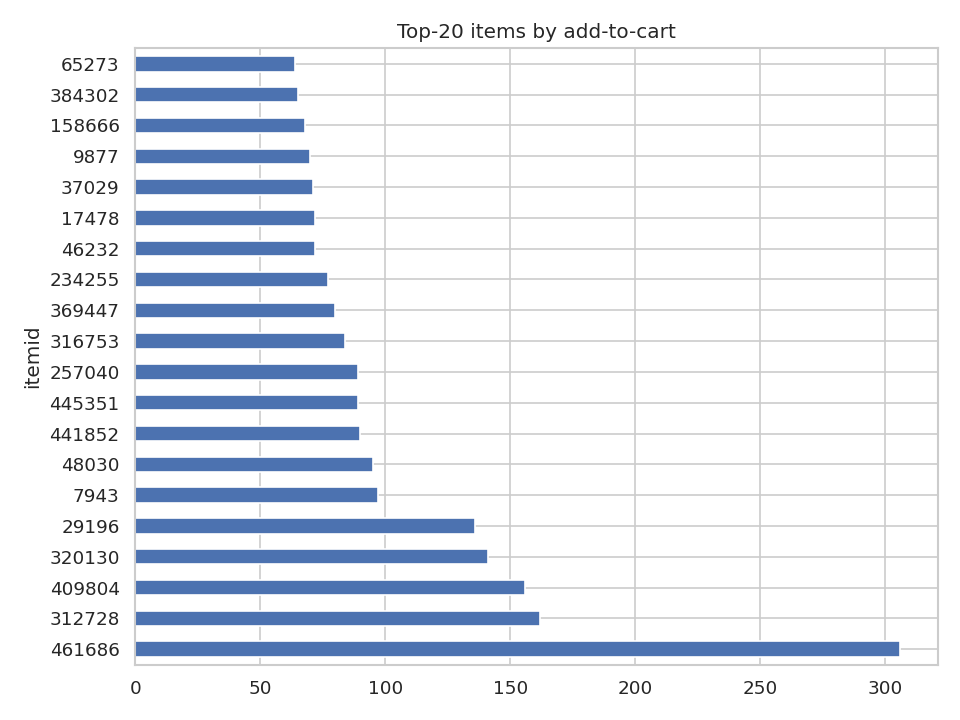

In [2]:
from IPython.display import Image, display
from src.config import ARTIFACTS_DIR
from src.eda import run_eda

summary = run_eda()
for name in ['event_distribution.png','events_daily.png','top_cart_items.png']:
    display(Image(filename=str(ARTIFACTS_DIR / 'eda' / name)))

## Выводы по EDA

1. **Дисбаланс событий:** основная масса — `view` (около 96.7%), `addtocart` и `transaction` редкие. Поэтому рекомендации должны работать в режиме implicit feedback с весами событий.
2. **Целевая метрика:** для бизнес-цели роста корзины оптимизируем add-to-cart, а не просто просмотры. Это отражено в `recall@10`, `hit_rate@10`, `map@10`.
3. **Длинный хвост товаров:** небольшое число items собирает много add-to-cart, поэтому popularity baseline обязателен для cold-start.
4. **Временная природа данных:** корректная валидация — только temporal split (train в прошлом, test в будущем), чтобы избежать утечки.
5. **Категории полезны для будущих улучшений:** category tree и item properties можно использовать для rerank/контекстных фич, но baseline production-версия строится на event-матрице user-item.

### Практический итог EDA

Для production-версии выбираем двухэтапную стратегию: ALS для генерации кандидатов + reranker с категорийными признаками. Это баланс между качеством, скоростью ответа API и устойчивостью к cold-start.